# 03 - Feature Engineering

## 1. Setup: city coordinates, wind direction mapping, helper functions

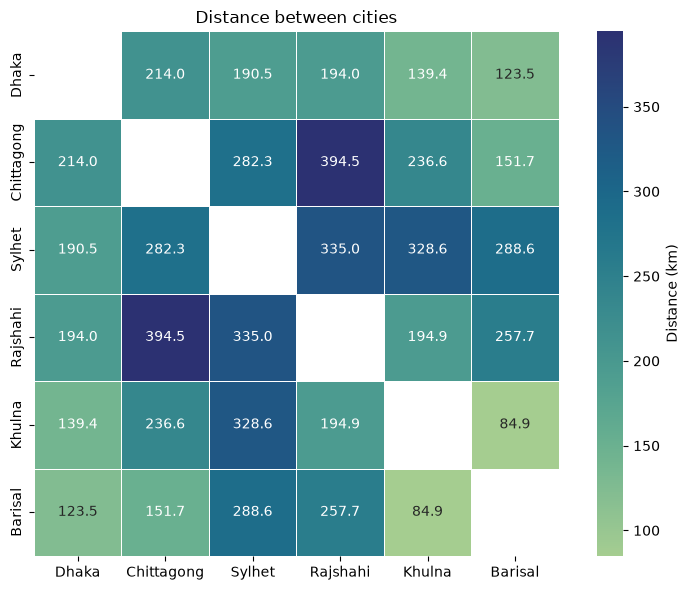

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

SPIKE_THRESHOLD = 150
HORIZONS = [1, 2, 3]  # hours ahead

CITY_COORDS = {
    "Dhaka":      (23.8103, 90.4125),
    "Chittagong": (22.3569, 91.7832),
    "Sylhet":     (24.8949, 91.8687),
    "Rajshahi":   (24.3745, 88.6042),
    "Khulna":     (22.8456, 89.5403),
    "Barisal":    (22.7010, 90.3535),
}

# 16-point compass -> degrees (N=0, clockwise)
WD_TO_DEG = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_distance_matrix(coords):
    cities = list(coords.keys())
    dist = pd.DataFrame(index=cities, columns=cities, dtype=float)
    for a in cities:
        for b in cities:
            dist.loc[a, b] = np.nan if a == b else haversine(*coords[a], *coords[b])
    return dist

dist_matrix = build_distance_matrix(CITY_COORDS)

plt.figure(figsize=(8, 6))
sns.heatmap(
    dist_matrix,
    annot=True,
    fmt=".1f",
    cmap="crest",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Distance (km)"}
)
plt.title("Distance between cities")
plt.tight_layout()
plt.show()

## 2. Load cleaned train/test data

In [14]:
train = pd.read_csv("train_clean.csv")
test = pd.read_csv("test_clean.csv")
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])
train = train.sort_values(["station", "datetime"]).reset_index(drop=True)
test = test.sort_values(["station", "datetime"]).reset_index(drop=True)
train.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,173641,2022,8,4,0,7.4,11.6,0.4,2.0,117.0,28.0,26.3,1003.8,25.0,0.0,SE,3.68,Barisal,2022-08-04 00:00:00
1,173642,2022,8,4,1,5.0,8.1,0.4,2.0,117.0,28.0,26.8,1004.8,24.8,0.1,SE,3.70,Barisal,2022-08-04 01:00:00
2,173643,2022,8,4,2,4.7,7.5,0.4,2.1,117.0,28.0,28.2,1004.5,25.0,0.0,SE,4.56,Barisal,2022-08-04 02:00:00
3,173644,2022,8,4,3,4.9,7.7,0.4,2.1,117.0,29.0,28.9,1004.8,25.1,0.0,SE,4.20,Barisal,2022-08-04 03:00:00
4,173645,2022,8,4,4,5.2,8.1,0.4,1.7,117.0,32.0,30.1,1004.6,25.4,0.2,SE,4.18,Barisal,2022-08-04 04:00:00


## 3. Temporal features
Cyclical encode hour & month with sin/cos so, e.g., 23:00 and 00:00 aren't
treated as far apart the way a raw integer would.

In [15]:
def add_temporal_features(df):
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dayofweek"] = pd.to_datetime(df["datetime"]).dt.dayofweek
    return df

train = add_temporal_features(train)
test = add_temporal_features(test)
train[["hour", "hour_sin", "hour_cos", "month", "month_sin", "month_cos"]].head()

,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,0,0.000000,1.000000,8,-0.866025,-0.5
1,1,0.258819,0.965926,8,-0.866025,-0.5
2,2,0.500000,0.866025,8,-0.866025,-0.5
3,3,0.707107,0.707107,8,-0.866025,-0.5
4,4,0.866025,0.500000,8,-0.866025,-0.5


## 4. Wind vector decomposition
Converts the categorical `wd` column into continuous U/V velocity components,
matching the proposal's formula:
`U = -WSPM * sin(theta)`, `V = -WSPM * cos(theta)`

In [16]:
def add_wind_vectors(df):
    deg = df["wd"].map(WD_TO_DEG)
    theta = np.radians(deg)
    df["wind_u"] = -df["WSPM"] * np.sin(theta)
    df["wind_v"] = -df["WSPM"] * np.cos(theta)
    return df

train = add_wind_vectors(train)
test = add_wind_vectors(test)
train[["wd", "WSPM", "wind_u", "wind_v"]].head()

,wd,WSPM,wind_u,wind_v
0,SE,3.68,-2.602153,2.602153
1,SE,3.70,-2.616295,2.616295
2,SE,4.56,-3.224407,3.224407
3,SE,4.20,-2.969848,2.969848
4,SE,4.18,-2.955706,2.955706


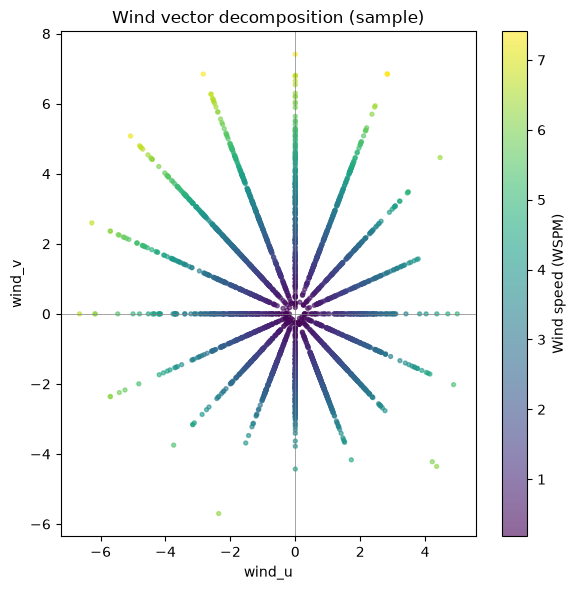

In [17]:
# quick visual check: wind vectors on a scatter (U vs V), colored by speed
plt.figure(figsize=(6, 6))
sample = train.sample(3000, random_state=42)
sc = plt.scatter(sample["wind_u"], sample["wind_v"], c=sample["WSPM"], cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, label="Wind speed (WSPM)")
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("wind_u")
plt.ylabel("wind_v")
plt.title("Wind vector decomposition (sample)")
plt.tight_layout()
plt.show()

## 5. PM2.5 lag & rolling features
Per-station lag features (1,2,3,6,24h) and rolling mean/std - justified by
the autocorrelation analysis in the EDA notebook.

In [18]:
def add_lag_and_rolling_features(df):
    df = df.sort_values(["station", "datetime"])
    g = df.groupby("station")["PM2.5"]

    for lag in [1, 2, 3, 6, 24]:
        df[f"pm25_lag_{lag}"] = g.shift(lag)

    for window in [3, 6, 24]:
        df[f"pm25_roll_mean_{window}"] = (
            g.shift(1).rolling(window).mean().reset_index(level=0, drop=True)
        )
        df[f"pm25_roll_std_{window}"] = (
            g.shift(1).rolling(window).std().reset_index(level=0, drop=True)
        )
    return df

train = add_lag_and_rolling_features(train)
test = add_lag_and_rolling_features(test)
train[["station", "datetime", "PM2.5", "pm25_lag_1", "pm25_lag_24", "pm25_roll_mean_6"]].head(10)

,station,datetime,PM2.5,pm25_lag_1,pm25_lag_24,pm25_roll_mean_6
0,Barisal,2022-08-04 00:00:00,7.4,NaN,NaN,NaN
1,Barisal,2022-08-04 01:00:00,5.0,7.4,NaN,NaN
2,Barisal,2022-08-04 02:00:00,4.7,5.0,NaN,NaN
3,Barisal,2022-08-04 03:00:00,4.9,4.7,NaN,NaN
4,Barisal,2022-08-04 04:00:00,5.2,4.9,NaN,NaN
5,Barisal,2022-08-04 05:00:00,6.0,5.2,NaN,NaN
6,Barisal,2022-08-04 06:00:00,6.1,6.0,NaN,5.533333
7,Barisal,2022-08-04 07:00:00,5.8,6.1,NaN,5.316667
8,Barisal,2022-08-04 08:00:00,5.8,5.8,NaN,5.450000
9,Barisal,2022-08-04 09:00:00,6.3,5.8,NaN,5.633333


## 6. IDW spatial lag features
For each city at each timestamp, computes the Inverse-Distance-Weighted
PM2.5 (and wind U/V) of the other 5 cities:
`w(i,j) = 1/d(i,j)^2` - closer cities get more influence, matching the
proposal's spatial lag formula.

In [19]:
def add_idw_spatial_lags(df, dist_matrix, power=2):
    pivot_pm25 = df.pivot(index="datetime", columns="station", values="PM2.5")
    pivot_u = df.pivot(index="datetime", columns="station", values="wind_u")
    pivot_v = df.pivot(index="datetime", columns="station", values="wind_v")

    cities = dist_matrix.index.tolist()
    idw_pm25 = pd.DataFrame(index=pivot_pm25.index, columns=cities, dtype=float)
    idw_u = pd.DataFrame(index=pivot_u.index, columns=cities, dtype=float)
    idw_v = pd.DataFrame(index=pivot_v.index, columns=cities, dtype=float)

    for city in cities:
        others = [c for c in cities if c != city]
        weights = np.array([1.0 / (dist_matrix.loc[city, o] ** power) for o in others])
        weights = weights / weights.sum()

        idw_pm25[city] = pivot_pm25[others].mul(weights, axis=1).sum(axis=1)
        idw_u[city] = pivot_u[others].mul(weights, axis=1).sum(axis=1)
        idw_v[city] = pivot_v[others].mul(weights, axis=1).sum(axis=1)

    idw_pm25 = idw_pm25.stack().rename("idw_pm25_neighbors").reset_index()
    idw_pm25.columns = ["datetime", "station", "idw_pm25_neighbors"]
    idw_u = idw_u.stack().rename("idw_wind_u_neighbors").reset_index()
    idw_u.columns = ["datetime", "station", "idw_wind_u_neighbors"]
    idw_v = idw_v.stack().rename("idw_wind_v_neighbors").reset_index()
    idw_v.columns = ["datetime", "station", "idw_wind_v_neighbors"]

    df = df.merge(idw_pm25, on=["datetime", "station"], how="left")
    df = df.merge(idw_u, on=["datetime", "station"], how="left")
    df = df.merge(idw_v, on=["datetime", "station"], how="left")
    return df

train = add_idw_spatial_lags(train, dist_matrix)
test = add_idw_spatial_lags(test, dist_matrix)
train[["station", "datetime", "PM2.5", "idw_pm25_neighbors"]].head()

,station,datetime,PM2.5,idw_pm25_neighbors
0,Barisal,2022-08-04 00:00:00,7.4,9.521187
1,Barisal,2022-08-04 01:00:00,5.0,7.282790
2,Barisal,2022-08-04 02:00:00,4.7,7.358604
3,Barisal,2022-08-04 03:00:00,4.9,6.482581
4,Barisal,2022-08-04 04:00:00,5.2,6.775147


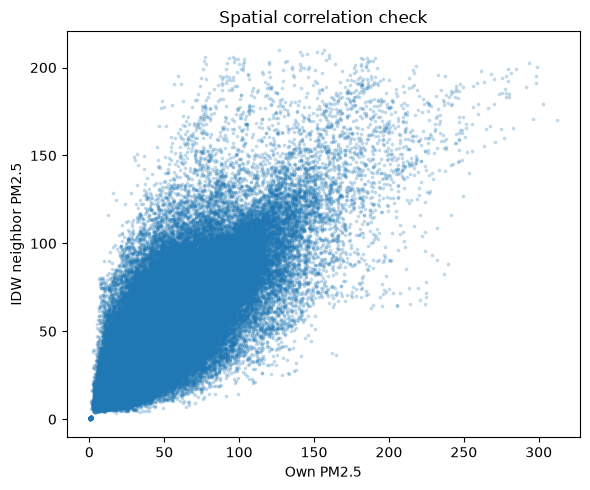

Correlation: 0.8325286391634694


In [20]:
# sanity check: own PM2.5 vs IDW-weighted neighbor PM2.5 should be correlated
plt.figure(figsize=(6, 5))
plt.scatter(train["PM2.5"], train["idw_pm25_neighbors"], s=3, alpha=0.2)
plt.xlabel("Own PM2.5")
plt.ylabel("IDW neighbor PM2.5")
plt.title("Spatial correlation check")
plt.tight_layout()
plt.show()
print("Correlation:", train["PM2.5"].corr(train["idw_pm25_neighbors"]))

## 7. Simple regional co-occurrence feature (precursor to ST-DBSCAN/Apriori)

In [21]:
def add_simple_pattern_features(df):
    ELEVATED = 100
    pivot = df.pivot(index="datetime", columns="station", values="PM2.5")
    elevated_count = (pivot > ELEVATED).sum(axis=1)
    n_stations = pivot.shape[1]
    elevated_frac_others = pd.DataFrame(index=pivot.index)
    for city in pivot.columns:
        others_elevated = elevated_count - (pivot[city] > ELEVATED).astype(int)
        elevated_frac_others[city] = others_elevated / (n_stations - 1)
    elevated_frac_others = elevated_frac_others.stack().rename(
        "regional_elevated_frac").reset_index()
    elevated_frac_others.columns = ["datetime", "station", "regional_elevated_frac"]
    return df.merge(elevated_frac_others, on=["datetime", "station"], how="left")

train = add_simple_pattern_features(train)
test = add_simple_pattern_features(test)

## 8. Spike targets (t+1, t+2, t+3)
Binary label per station: `1 if PM2.5[t+k] > 150 else 0`

In [22]:
def add_spike_targets(df, horizons, threshold):
    df = df.sort_values(["station", "datetime"])
    for h in horizons:
        df[f"spike_t+{h}"] = (
            df.groupby("station")["PM2.5"].shift(-h) > threshold
        ).astype("Int64")
    return df

train = add_spike_targets(train, HORIZONS, SPIKE_THRESHOLD)
test = add_spike_targets(test, HORIZONS, SPIKE_THRESHOLD)

for h in HORIZONS:
    rate = train[f"spike_t+{h}"].astype(float).mean() * 100
    print(f"Spike rate at t+{h}: {rate:.3f}%")

Spike rate at t+1: 0.881%
Spike rate at t+2: 0.881%
Spike rate at t+3: 0.881%


## 9. Drop edge NaNs (from lags/rolling/targets) and save

In [23]:
def finalize(df, label):
    before = len(df)
    df = df.dropna(subset=["pm25_lag_24"] + [f"spike_t+{h}" for h in HORIZONS])
    after = len(df)
    print(f"[{label}] dropped {before - after} edge rows -> {after} rows remain")
    return df

train = finalize(train, "train")
test = finalize(test, "test")

train.to_csv("train_features.csv", index=False)
test.to_csv("test_features.csv", index=False)
print("Saved train_features.csv", train.shape, "and test_features.csv", test.shape)

[train] dropped 144 edge rows -> 179280 rows remain
[test] dropped 144 edge rows -> 28800 rows remain
Saved train_features.csv (179280, 44) and test_features.csv (28800, 44)
